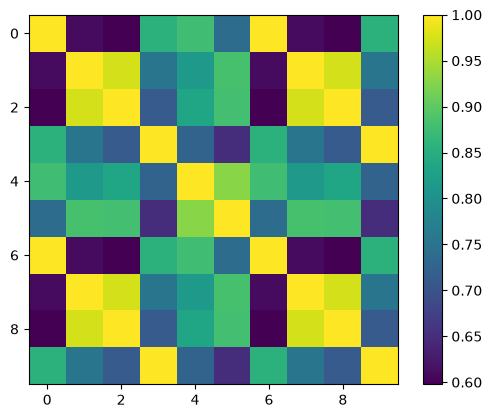

In [6]:
from domain.character_profile import CharacterProfile
from domain.similarity_engine import SimilarityEngine
import numpy as np
import matplotlib.pyplot as plt

status1 = CharacterProfile(80, 70, 20, 90, 30)
status2 = CharacterProfile(20, 65, 95, 25, 85)
status3 = CharacterProfile(30, 30, 70, 15, 70)
status4 = CharacterProfile(60, 85, 30, 20, 30)
status5 = CharacterProfile(50, 30, 60, 80, 54)
status6 = CharacterProfile(10, 20, 30, 40, 50)
status7 = CharacterProfile(80, 70, 20, 90, 30)
status8 = CharacterProfile(20, 65, 95, 25, 85)
status9 = CharacterProfile(30, 30, 70, 15, 70)
status10 = CharacterProfile(60, 85, 30, 20, 30)
all_status = [status1, status2, status3, status4, status5, status6, status7, status8, status9, status10]
matriz_similaridade = SimilarityEngine(all_status)
n = len(all_status)
matriz = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matriz[i][j] = matriz_similaridade.similarity(all_status[i], all_status[j]) 

plt.imshow(matriz, cmap='viridis')
plt.colorbar()
plt.show()




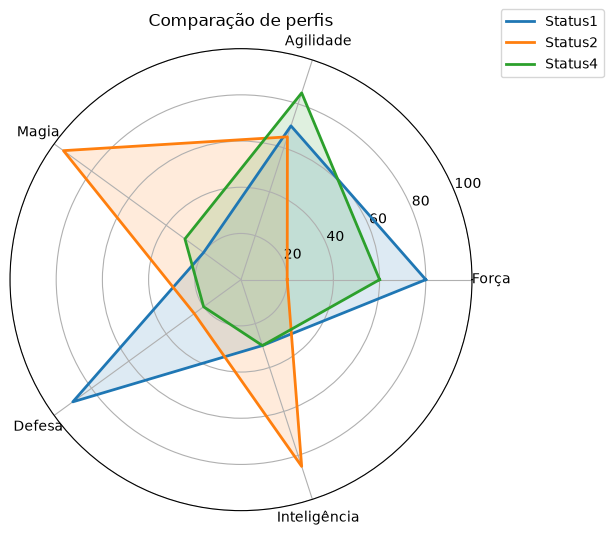

In [7]:
def plot_radar(profiles, labels, attribute_names=["Força", "Agilidade", "Magia", "Defesa", "Inteligência"]):
    n_attrs = len(attribute_names)
    angles = np.linspace(0, 2 * np.pi, n_attrs, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for profile, label in zip(profiles, labels):
        values = list(profile.status) + [profile.status[0]]
        ax.plot(angles, values, linewidth=2, label=label)
        ax.fill(angles, values, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(attribute_names)
    ax.set_ylim(0, 100)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.title("Comparação de perfis")
    plt.show()

plot_radar([status1, status2, status4], ["Status1", "Status2", "Status4"])

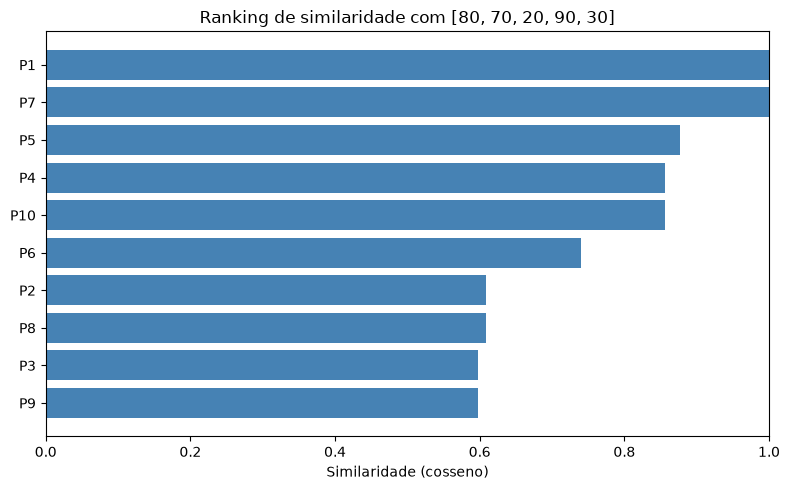

In [8]:
def plot_similarity_ranking(engine, reference, all_profiles, labels):
    scores = [engine.similarity(reference, p) for p in all_profiles]
    pairs = sorted(zip(labels, scores), key=lambda x: x[1], reverse=True)
    names, values = zip(*pairs)

    plt.figure(figsize=(8, 5))
    plt.barh(names, values, color="steelblue")
    plt.xlabel("Similaridade (cosseno)")
    plt.title(f"Ranking de similaridade com {reference}")
    plt.xlim(0, 1)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

labels = [f"P{i+1}" for i in range(len(all_status))]
plot_similarity_ranking(matriz_similaridade, status1, all_status, labels)

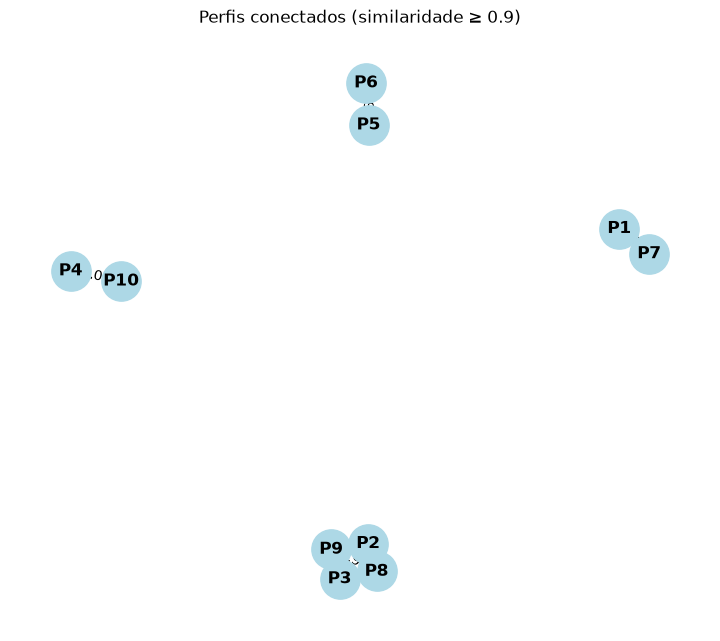

In [9]:
import networkx as nx

def plot_similarity_graph(engine, all_profiles, labels, threshold=0.9):
    G = nx.Graph()
    G.add_nodes_from(labels)

    n = len(all_profiles)
    for i in range(n):
        for j in range(i + 1, n):
            sim = engine.similarity(all_profiles[i], all_profiles[j])
            if sim >= threshold:
                G.add_edge(labels[i], labels[j], weight=sim)

    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(7, 6))
    nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=800, font_weight="bold")
    edge_labels = {k: f"{v:.2f}" for k, v in nx.get_edge_attributes(G, "weight").items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title(f"Perfis conectados (similaridade ≥ {threshold})")
    plt.show()

plot_similarity_graph(matriz_similaridade, all_status, labels, threshold=0.9)